In [3]:
%load_ext autoreload
%autoreload 2

from eeg_eye.data import load
from eeg_eye.dataset import EEGEyeDataset
from eeg_eye.dataset import _segments
import numpy as np

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
X, y = load()

X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

2026-03-22 07:55:15.445 | INFO     | eeg_eye.data:download:29 - File exists


In [5]:
X_norm.shape

(14980, 14)

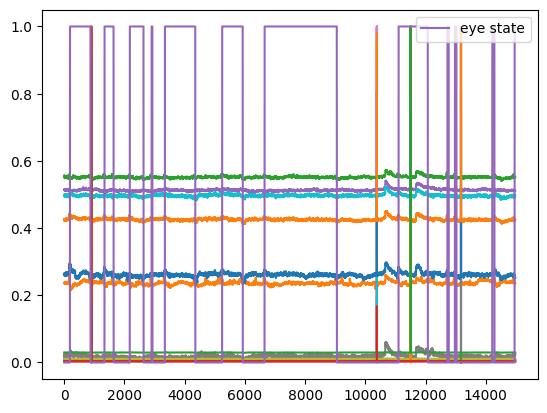

In [6]:
plt.plot(X_norm)
plt.plot(y, label="eye state")
plt.legend()

plt.show()

By eye there doesn't seem to a clear correlation between the signal and the eye state.

Let's zoom in a bit

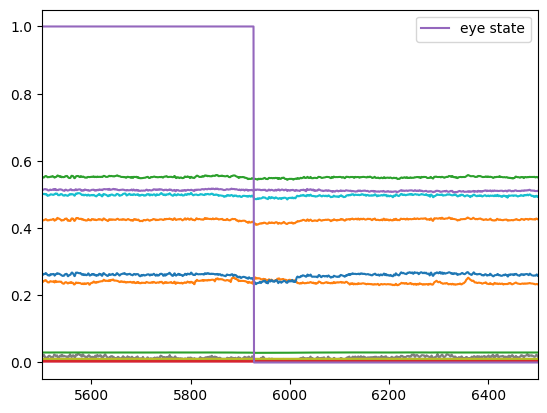

In [7]:
plt.plot(X_norm)
plt.plot(y, label="eye state")

plt.xlim(5500, 6500)
plt.legend()

plt.show()

Looking up close there seems to be some activity, some signals are changing. Let the model find out.

In [8]:
data_set = EEGEyeDataset()
segments = data_set.segments
lengths = np.array([x.shape[0] for x, y in data_set.segments])

min = np.min(lengths)
max = np.max(lengths)
avg = np.average(lengths)
median = np.median(lengths)

print(f"The min length is {min}, max is {max}, average is {avg:.2f} and the medidian is {median}")

2026-03-22 07:55:16.289 | INFO     | eeg_eye.data:download:29 - File exists


The min length is 21, max is 2401, average is 624.17 and the medidian is 501.5
